In [2]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import RandomizedSearchCV

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNetCV, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score


## Data preprocessing

In [4]:
file_path = "energydata_complete.csv"
df = pd.read_csv(file_path)
# Convert date column to datetime format (instead of object)
df['date'] = pd.to_datetime(df['date'])

# set date as index because we have 10min intervals i.e uniqueness 
df.set_index('date', inplace=True) 

# To analyse temporal tendencies and have meaningful features, we create the hour, day of the week, month and year features from the date index
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

X = df.drop(columns=['Appliances', 'rv1', 'rv2'])  
y = df['Appliances']

# Let's encode categorical variables using one-hot encoding
X = pd.get_dummies(X, columns=['month', 'day_of_week', 'hour'], drop_first=True)

In [13]:
X.head()

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,...,0,0,0,1,0,0,0,0,0,0
2016-01-11 17:10:00,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,...,0,0,0,1,0,0,0,0,0,0
2016-01-11 17:20:00,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,...,0,0,0,1,0,0,0,0,0,0
2016-01-11 17:30:00,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,...,0,0,0,1,0,0,0,0,0,0
2016-01-11 17:40:00,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,...,0,0,0,1,0,0,0,0,0,0


## Standarize and split into train and test

In [5]:
# Let's normalize the data to avoid bias towards any feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

In [6]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
# Check the shape of the train and test sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((15788, 58), (3947, 58), (15788, 1), (3947, 1))

In [7]:
from sklearn.decomposition import PCA

# Assume X_scaled is your preprocessed and standardized data
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Optional: print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Shape of PCA result:", X_pca.shape)


Explained variance ratio: [0.17354851 0.1258218  0.04063839]
Shape of PCA result: (19735, 3)


In [9]:
import plotly.express as px
import pandas as pd

# Create a DataFrame for easier plotting
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])

# Optional: add labels or categories
# df_pca['Label'] = labels

fig = px.scatter_3d(
    df_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    # color='Label',  # uncomment if you have labels
    title='Interactive 3D PCA Projection',
    opacity=0.7
)

fig.show()



<font color="red">Ici tu peux voir la relationentre chaque variable par rapport à Y

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Si X_train est un numpy array, on le convertit en DataFrame pour nommer les colonnes
X_df = pd.DataFrame(X_train, columns=[f"Feature_{i}" for i in range(X_train.shape[1])])

# Boucle sur chaque variable
for i in range(X_df.shape[1]):
    plt.figure(figsize=(6, 4))
    plt.scatter(X_df.iloc[:, i], y_train, alpha=0.5)
    plt.xlabel(f"Feature {i}")
    plt.ylabel("Y")
    plt.title(f"Y vs Feature {i}")
    plt.tight_layout()
    plt.show()


## Kernel regression

In [ ]:
# Lets fit Gaussian, polynomial and laplacian kernel and see which has better performances

param_grid = [
    {'kernel': ['rbf'], 'gamma': [0.1, 1], 'alpha': [0.1, 1]},
    {'kernel': ['poly'], 'degree': [2, 3], 'gamma': [0.1, 1], 'alpha': [0.1, 1]},
    {'kernel': ['laplacian'], 'gamma': [0.1, 1, 10], 'alpha': [0.1, 1, 10]}
]

model = RandomizedSearchCV(KernelRidge(), param_grid, cv=5, scoring='neg_mean_squared_error')
model.fit(X_train, y_train)
print("Best kernel:", model.best_params_)

# the answer is: the best kernel is a rbf with gamma and alpha =0.1

#### Standard regression metrics

In [9]:
# Initialize the model with RBF kernel and your chosen hyperparameters
model = KernelRidge(kernel='rbf', gamma=0.1, alpha=0.1)

# Fit the model to your training data
model.fit(X_train, y_train)

KernelRidge(alpha=0.1, gamma=0.1, kernel='rbf')

#### Residual analysis

In [ ]:
import matplotlib.pyplot as plt

def evaluate_kernel(model, X_train, X_test, y_train, y_test):
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print("Train R²:", r2_score(y_train, y_train_pred))
    print("Test R²:", r2_score(y_test, y_test_pred))
    print("Train MSE:", mean_squared_error(y_train, y_train_pred))
    print("Test MSE:", mean_squared_error(y_test, y_test_pred))
    print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
    print("Test MAE:", mean_absolute_error(y_test, y_test_pred))


    #scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    #print("Cross-validated R²:", scores.mean(), "±", scores.std())

    residuals = y_test - y_test_pred

    # Create a figure with 1 row and 2 columns of subplots
    fig, axs = plt.subplots(1, 3, figsize=(10, 4))

    # Residual Plot
    axs[0].scatter(y_test_pred, residuals, alpha=0.5)
    axs[0].axhline(y=0, color='r', linestyle='--')
    axs[0].set_xlabel("Predicted Values")
    axs[0].set_ylabel("Residuals")
    axs[0].set_title("Residual Plot")

    # Actual vs. Predicted Plot
    axs[1].scatter(y_test, y_test_pred, alpha=0.3)
    axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axs[1].set_xlabel("Actual Values")
    axs[1].set_ylabel("Predicted Values")
    axs[1].set_title("Actual vs. Predicted")

    #Plot 1: Predicted vs Actual (Line Plot)
    axs[2].plot(y_train, label='Actual train', color='blue', alpha=0.5)
    axs[2].plot(y_train_pred, label='Predicted train', color='orange', alpha=0.5)
    axs[2].set_xlabel('Sample Index')
    axs[2].set_ylabel('Target Value')
    axs[2].set_title('Predicted vs Actual (Line Plot)')
    axs[2].legend()
    
    # Adjust layout and show the plots
    plt.tight_layout()
    plt.show()

**Gaussian kernel**

Train R²: 0.8472234977880871
Test R²: 0.538677292672905
Train MSE: 0.1546022333126727
Test MSE: 0.4392138874340989
Train MAE: 0.17825781395658866
Test MAE: 0.2976550751426096
Cross-validated R²: 0.4611728098948823 ± 0.0204483719277876


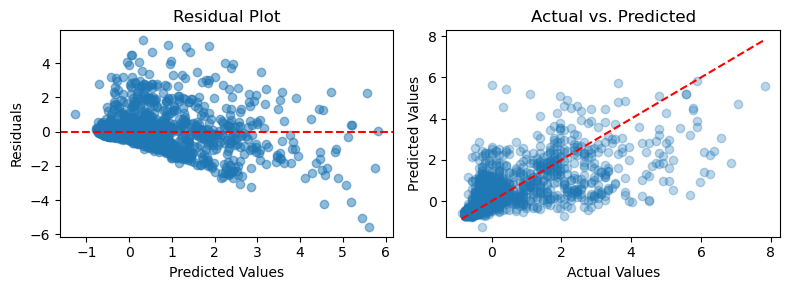

In [ ]:
evaluate_kernel(model, X_train, X_test, y_train, y_test)

with rbf alpha =0.1 and gamma=0.1,
Train R²: 0.8472234977880871

Test R²: 0.538677292672905

Train MSE: 0.1546022333126727

Test MSE: 0.4392138874340989

Train MAE: 0.17825781395658866

Test MAE: 0.2976550751426096

Cross-validated R²: 0.4611728098948823 ± 0.0204483719277876

Model seems robust.... idk

Residuals of 4,5... knowing that the data is in (0,6)... not so good

Train R²: 0.2988957282644603
Test R²: 0.1752658951330942
Train MSE: 0.7094827059531764
Test MSE: 0.7852088495640375
Train MAE: 0.47034124334902244
Test MAE: 0.5014660571289438


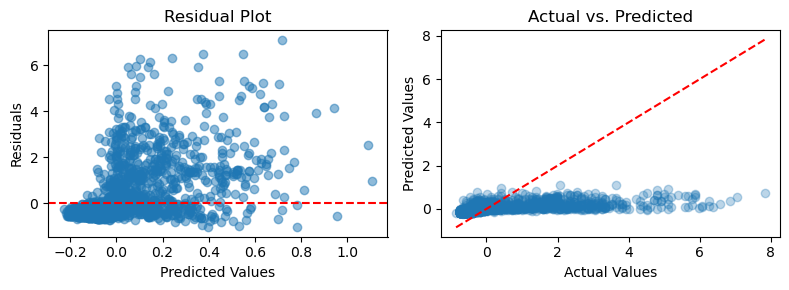

In [7]:
model2 = KernelRidge(kernel='rbf', gamma=0.8, alpha=10)
model2.fit(X_train, y_train)
evaluate_kernel(model2, X_train, X_test, y_train, y_test)


The model with large gamma and high alpha is very bad. Since alpha is the Regularization Strength, with an alpha so high, we might have done an underfitting (model too simple), a mild regularisation was better

Train R²: 0.8981505620055428
Test R²: 0.5389673997846436
Train MSE: 0.1030665733775115
Test MSE: 0.43893768366113206
Train MAE: 0.13986654567812012
Test MAE: 0.28867416036307114


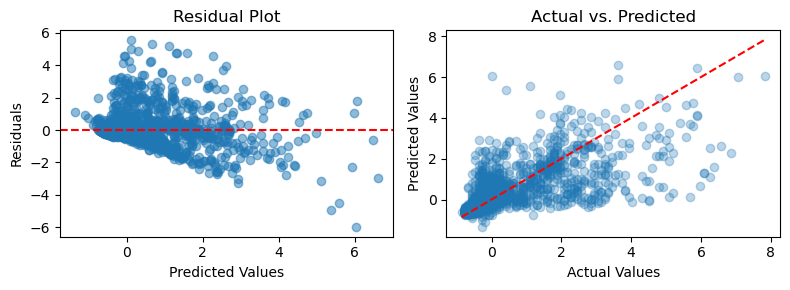

In [10]:
model3 = KernelRidge(kernel='rbf', gamma=0.3, alpha=0.1)
model3.fit(X_train, y_train)
evaluate_kernel(model3, X_train, X_test, y_train, y_test)

I think i've reached the best parameters for the rbf kernel. gamma=0.3, alpha=0.1.

**Polynomial Kernel**

We see a clear overfitting with polynomial kernel degree=8, gamma=0.3.

Train R²: 0.9997422687929342
Test R²: -4466.494732900487
Train MSE: 0.0002608111825434637
Test MSE: 4253.390733999402

Performances are better with polynomial kernel degree=2, gamma=0.2, the model's simpler (lower gamma and lower degree)
Train R²: 0.5022838369605704
Test R²: 0.3745466563026649
Train MSE: 0.5036640402656768
Test MSE: 0.595478588265511
Train MAE: 0.4117436741398153
Test MAE: 0.45513317832437233

Performances are better with polynomial kernel degree=3, gamma=0.2

Train R²: 0.8997764359835897
Test R²: 0.3550595232884769
Train MSE: 0.10142126965310533
Test MSE: 0.6140318034230694
Train MAE: 0.16984592938001186
Test MAE: 0.3978492545988923

Train R²: 0.8997764359835897
Test R²: 0.3550595232884769
Train MSE: 0.10142126965310533
Test MSE: 0.6140318034230694
Train MAE: 0.16984592938001186
Test MAE: 0.3978492545988923


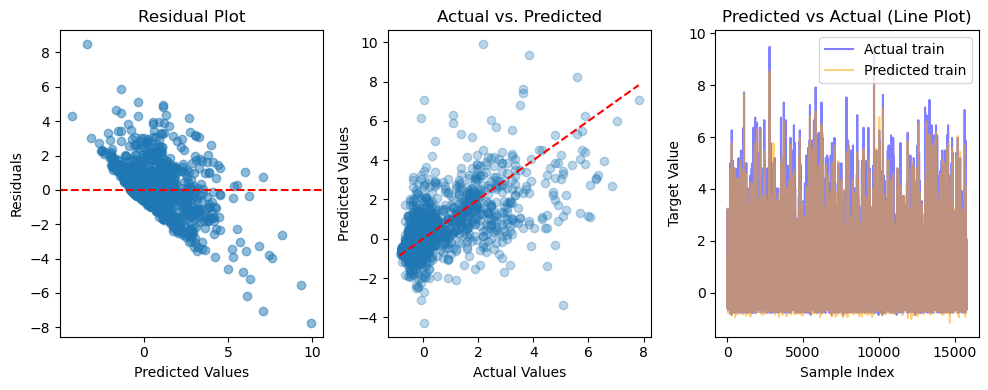

In [12]:
model4 = KernelRidge(kernel='poly', degree=3, gamma=0.2)
model4.fit(X_train, y_train)
evaluate_kernel(model4, X_train, X_test, y_train, y_test)

## Try to find the best parameters for a gaussian kernel
<font color="red">Cette fonction écrase mon kernel, mon ordi pete si je la lance!!!!! 

In [ ]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

param_grid = {
    'kernel': ['rbf'],
    'gamma': [0.2, 0.5],    # Vos valeurs de gamma
    'alpha': [0.01, 0.2]     # Vos valeurs d'alpha
}

model = KernelRidge()
scorer = make_scorer(mean_squared_error, greater_is_better=False)
grid_search = GridSearchCV(
    model, 
    param_grid, 
    cv=5,                          # 5 folds de validation croisée
    scoring='neg_mean_squared_error', # Minimiser la MSE
    n_jobs=-1                      # Paralléliser sur tous les cœurs
)

# executer ave
grid_search.fit(X_train, y_train)

print("Meilleurs paramètres:", grid_search.best_params_)
print("Meilleur score (MSE):", -grid_search.best_score_)  # Convertir en MSE positif

best_model = grid_search.best_estimator_
y_test_pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
print("MSE sur le test set:", test_mse)
